# Task 5: Exploratory Data Analysis (EDA) — Titanic Dataset

### Elevate Labs Data Analyst Internship

**Objective:** Extract insights using visual and statistical exploration.

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

## 1. Introduction

This project performs Exploratory Data Analysis (EDA) on the Titanic dataset.

The objective is to understand the structure of the dataset, examine statistical characteristics, identify relationships between variables, detect anomalies and outliers, and extract meaningful insights using visualizations and statistical techniques.

## 2. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a clean visualization style
sns.set_theme(style="whitegrid")

In [3]:
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 3. Loading the Dataset

In [5]:
# Load the Titanic dataset

df = pd.read_csv('/train.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 4. Dataset Overview

This section examines the structure, dimensions, data types, and statistical characteristics of the dataset.

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Statistical summary of numerical columns

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# Statistical summary including categorical columns

df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## 5. Data Quality Analysis

This section examines missing values, duplicate records, and data types to assess the quality and completeness of the dataset.

In [11]:
# Check for missing values in each column

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
# Percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


## 6. Categorical Variable Analysis

In [13]:
# Count passengers based on survival

df['Survived'].value_counts()

,count
Survived,
0,549
1,342


## 7. Survival Analysis

In [14]:
# Survival percentage

df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


In [15]:
# Count passengers by gender

df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [16]:
# Count passengers in each passenger class

df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [17]:
# Count passengers by port of embarkation

df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


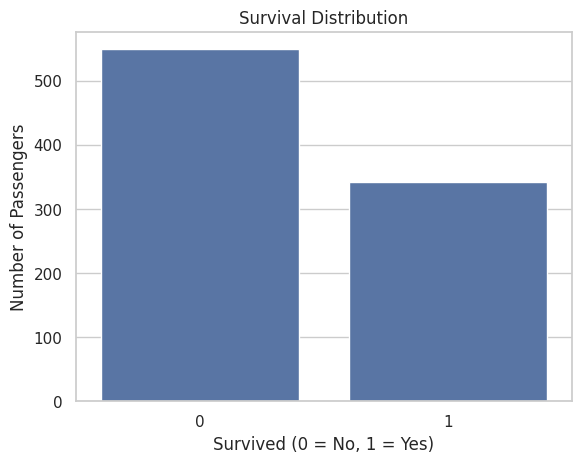

In [18]:
# Bar chart of survival distribution

sns.countplot(x='Survived', data=df)

plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

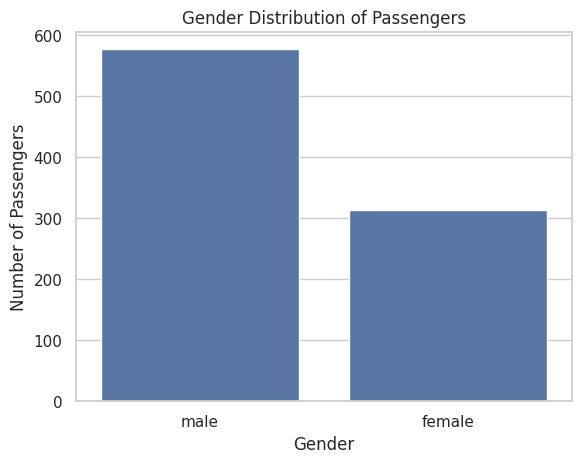

In [19]:
# Bar chart of gender distribution

sns.countplot(x='Sex', data=df)

plt.title('Gender Distribution of Passengers')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

Observation: The chart shows the distribution of male and female passengers in the Titanic dataset. Male passengers were more numerous than female passengers.

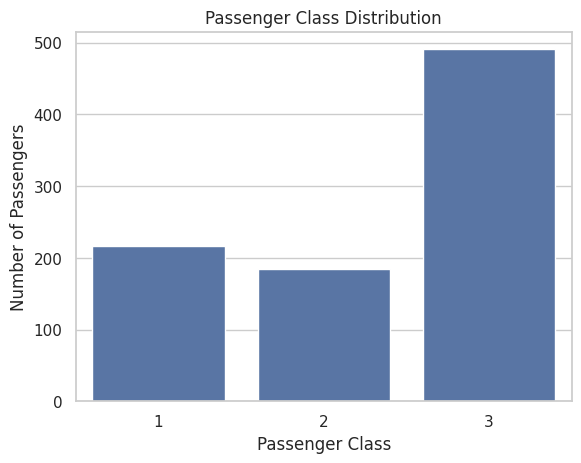

In [20]:
# Bar chart of passenger class distribution

sns.countplot(x='Pclass', data=df)

plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

Observation: 1st-class passengers had the highest survival rate, while 3rd-class passengers had the lowest.

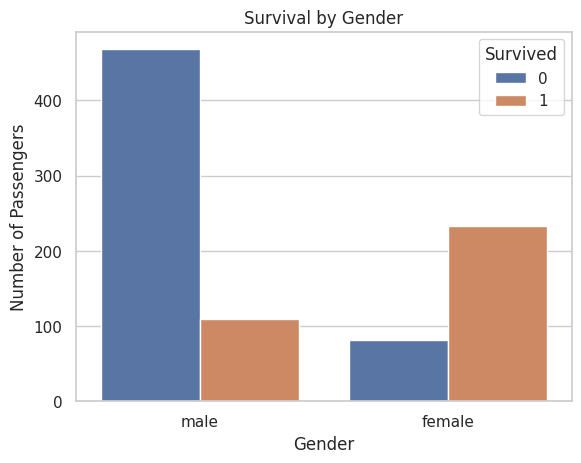

In [21]:
# Survival by gender

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

Observation: Female passengers had a significantly higher survival rate than male passengers. This indicates that gender was an important factor associated with survival on the Titanic.

In [22]:
# Survival rate by gender

df.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


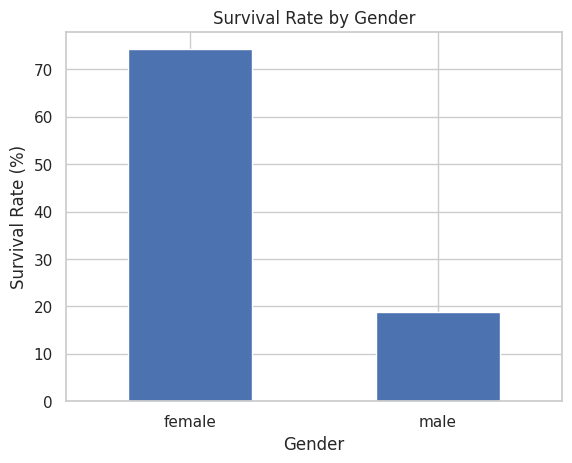

In [23]:
# Survival rate by gender

survival_gender = df.groupby('Sex')['Survived'].mean() * 100

survival_gender.plot(kind='bar')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)

plt.show()

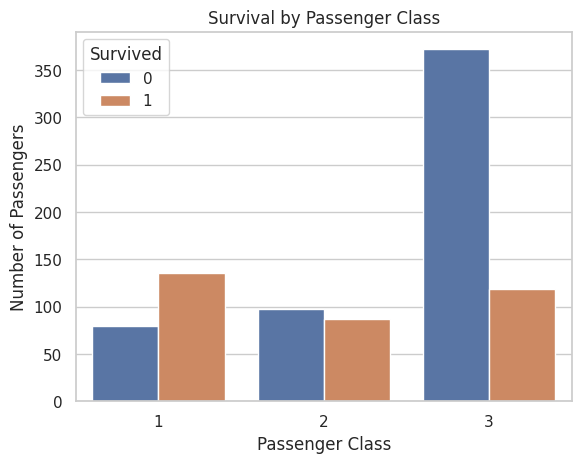

In [24]:
# Survival by passenger class

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

In [25]:
# Survival rate by passenger class

df.groupby('Pclass')['Survived'].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


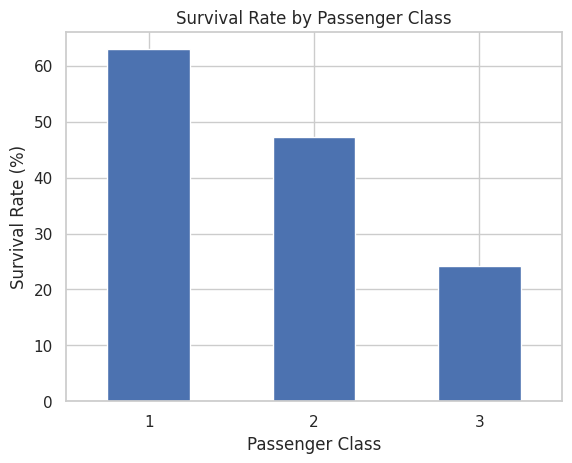

In [26]:
# Plot survival rate by passenger class

survival_class = df.groupby('Pclass')['Survived'].mean() * 100

survival_class.plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)

plt.show()

## 8. Numerical Variable Analysis

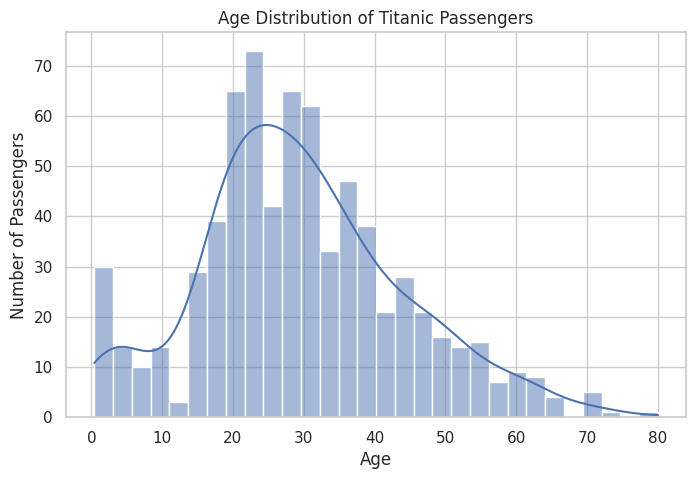

In [27]:
# Age distribution

plt.figure(figsize=(8, 5))

sns.histplot(df['Age'].dropna(), bins=30, kde=True)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

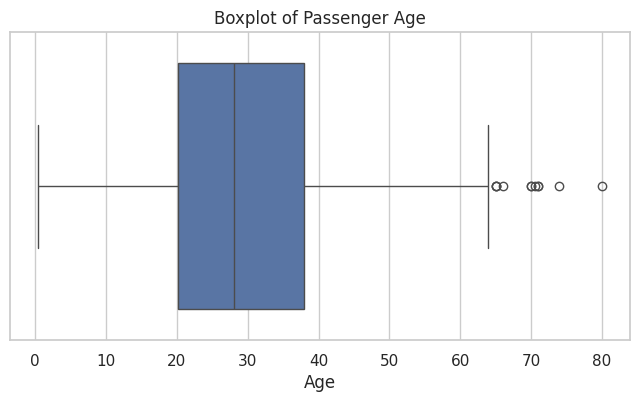

In [28]:
# Boxplot of passenger age

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Age'])

plt.title('Boxplot of Passenger Age')
plt.xlabel('Age')

plt.show()

In [29]:
# Statistical summary of Age

df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


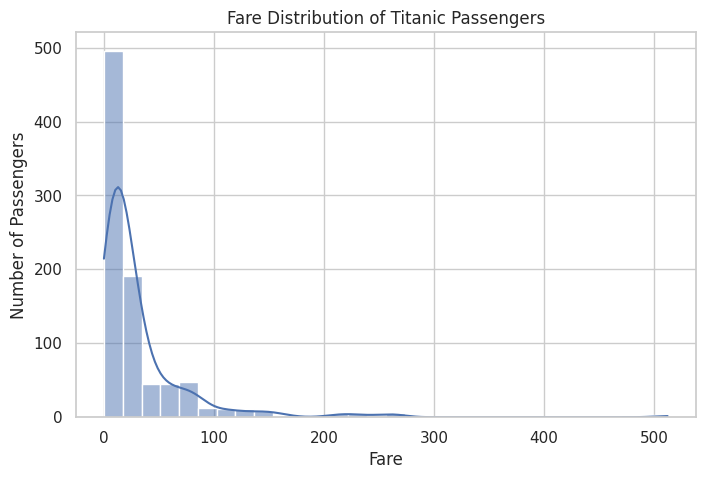

In [30]:
# Fare distribution

plt.figure(figsize=(8, 5))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title('Fare Distribution of Titanic Passengers')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')

plt.show()

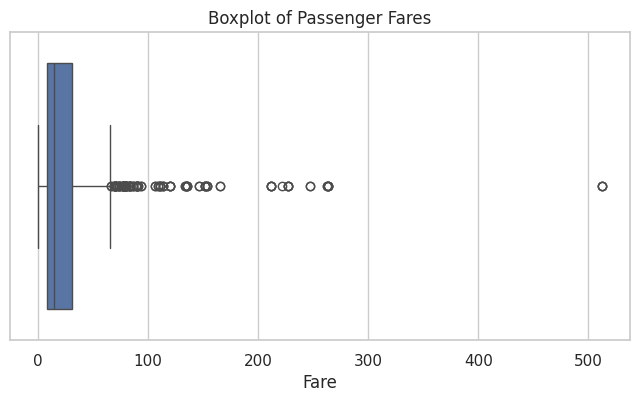

In [31]:
# Boxplot of passenger fares

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Fare'])

plt.title('Boxplot of Passenger Fares')
plt.xlabel('Fare')

plt.show()

In [32]:
# Statistical summary of Fare

df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


## 9. Relationship Analysis

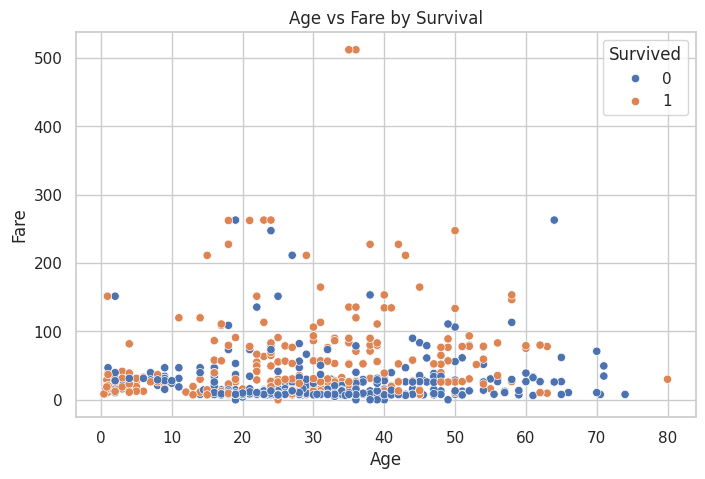

In [33]:
# Scatterplot: Age vs Fare

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')

plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

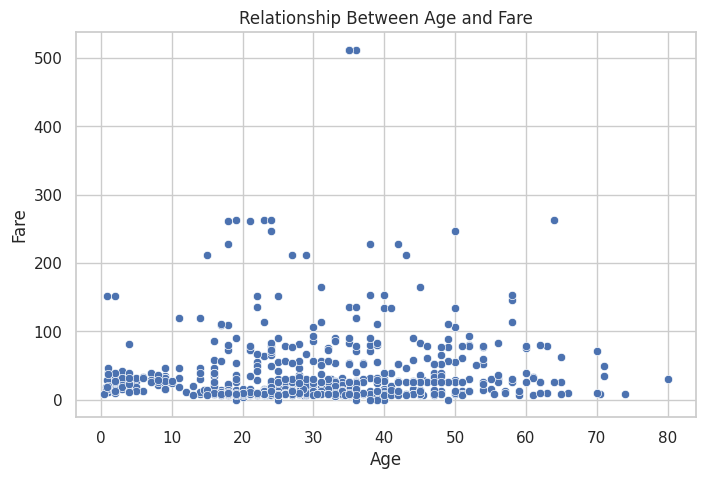

In [34]:
# Scatterplot: Age vs Fare

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Fare')

plt.title('Relationship Between Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

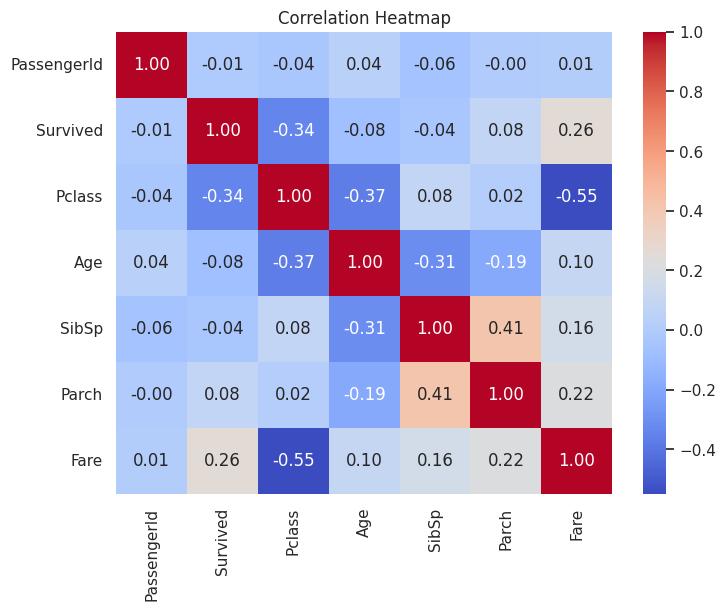

In [35]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

## 10. Multivariate Analysis

This section examines the combined relationship between gender, passenger class, and survival.

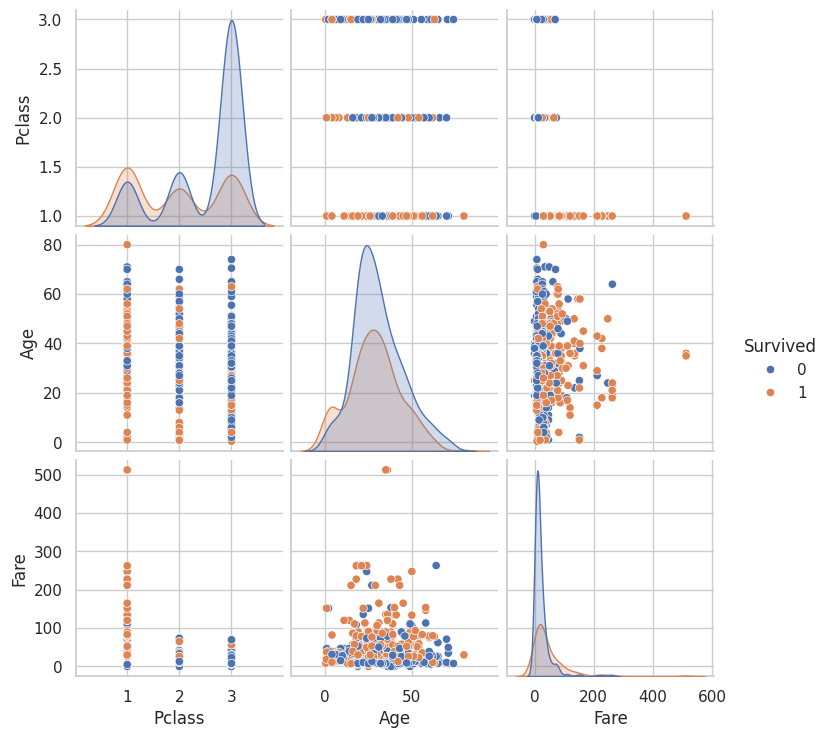

In [36]:
# Pairplot of selected Titanic variables

sns.pairplot(
    df[['Survived', 'Pclass', 'Age', 'Fare']],
    hue='Survived'
)

plt.show()

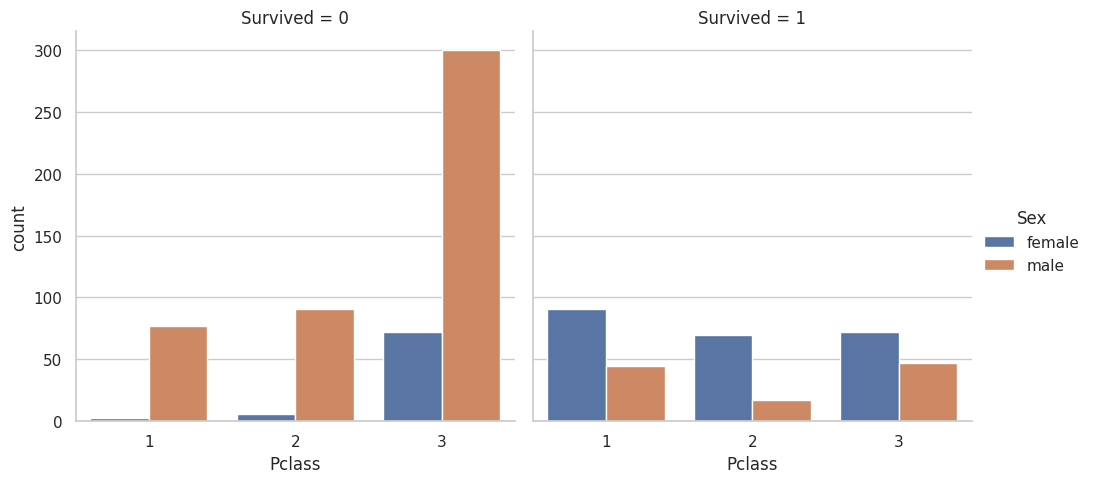

In [37]:
# Survival by gender and passenger class

sns.catplot(
    data=df,
    x='Pclass',
    hue='Sex',
    col='Survived',
    kind='count',
    height=5,
    aspect=1
)

plt.show()

In [38]:
# Survival rate by gender and passenger class

survival_gender_class = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100

survival_gender_class

Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64

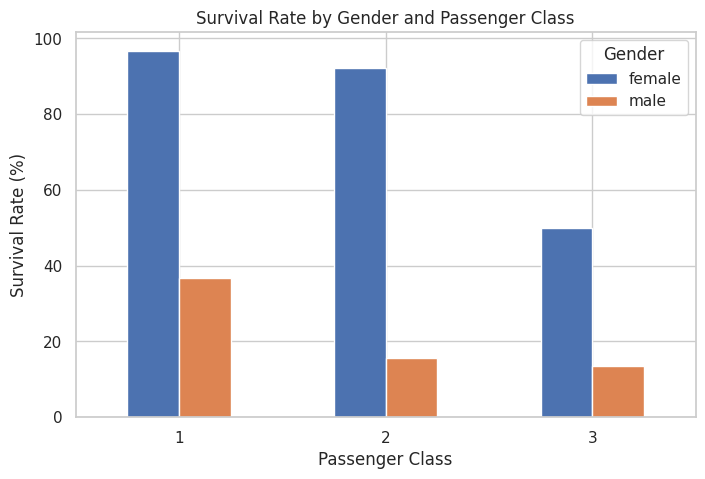

In [39]:
# Visualize survival rate by gender and passenger class

survival_gender_class.unstack().plot(kind='bar', figsize=(8, 5))

plt.title('Survival Rate by Gender and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)

plt.legend(title='Gender')
plt.show()

## 11. Outlier and Anomaly Analysis

Potential outliers were investigated using the Interquartile Range (IQR) method. Outliers were identified but not automatically removed because unusual values may represent valid observations.

In [40]:
# Detect Fare outliers using the IQR method

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

fare_outliers = df[
    (df['Fare'] < lower_limit) |
    (df['Fare'] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of Fare outliers:", len(fare_outliers))

Lower limit: -26.724
Upper limit: 65.6344
Number of Fare outliers: 116


In [41]:
# Display passengers with the highest fares

df[['Name', 'Pclass', 'Fare', 'Survived']].sort_values(
    by='Fare',
    ascending=False
).head(10)

,Name,Pclass,Fare,Survived
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
258,"Ward, Miss. Anna",1,512.3292,1
737,"Lesurer, Mr. Gustave J",1,512.3292,1
88,"Fortune, Miss. Mabel Helen",1,263.0000,1
438,"Fortune, Mr. Mark",1,263.0000,0
341,"Fortune, Miss. Alice Elizabeth",1,263.0000,1
27,"Fortune, Mr. Charles Alexander",1,263.0000,0
742,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750,1
311,"Ryerson, Miss. Emily Borie",1,262.3750,1
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1,247.5208,1


In [42]:
# Detect Age outliers using the IQR method

Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)

IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df['Age'] < lower_age) |
    (df['Age'] > upper_age)
]

print("Lower age limit:", lower_age)
print("Upper age limit:", upper_age)
print("Number of Age outliers:", len(age_outliers))

Lower age limit: -6.6875
Upper age limit: 64.8125
Number of Age outliers: 11


In [43]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [44]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [45]:
# Check data types

df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [46]:
# Overall dataset summary

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Dataset shape: (891, 12)
Total missing values: 866
Total duplicate rows: 0
Number of columns: 12
Number of rows: 891


In [47]:
# Overall survival rate

overall_survival = df['Survived'].mean() * 100

print(f"Overall survival rate: {overall_survival:.2f}%")

Overall survival rate: 38.38%


In [48]:
# Survival rate by gender

gender_survival = df.groupby('Sex')['Survived'].mean() * 100

print("Survival rate by gender:")
print(gender_survival.round(2))

Survival rate by gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [50]:
# Survival rate by passenger class

class_survival = df.groupby('Pclass')['Survived'].mean() * 100

print("Survival rate by passenger class:")
print(class_survival.round(2))

Survival rate by passenger class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [51]:
# Create age groups

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
)

age_group_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

print("Survival rate by age group:")
print(age_group_survival.round(2))

Survival rate by age group:
AgeGroup
Child          57.97
Teenager       42.86
Young Adult    38.27
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64


In [53]:
# Summary of key findings

findings = pd.DataFrame({
    'Analysis': [
        'Overall Survival',
        'Female Survival',
        'Male Survival',
        '1st Class Survival',
        '2nd Class Survival',
        '3rd Class Survival'
    ],
    'Survival Rate (%)': [
        overall_survival,
        gender_survival.get('female', np.nan),
        gender_survival.get('male', np.nan),
        class_survival.get(1, np.nan),
        class_survival.get(2, np.nan),
        class_survival.get(3, np.nan)
    ]
})

findings['Survival Rate (%)'] = findings['Survival Rate (%)'].round(2)

findings

,Analysis,Survival Rate (%)
0,Overall Survival,38.38
1,Female Survival,74.20
2,Male Survival,18.89
3,1st Class Survival,62.96
4,2nd Class Survival,47.28
5,3rd Class Survival,24.24


# 12. Key Findings and Conclusion

### Key Findings

1. Survival rates differed substantially between male and female passengers.
2. Passenger class was strongly associated with survival outcomes.
3. First-class passengers generally had higher survival rates than passengers in lower classes.
4. The age distribution showed passengers across a wide range of ages.
5. Fare distribution was right-skewed and contained potential high-value outliers.
6. The correlation analysis revealed relationships between several numerical variables.
7. Combined analysis of gender and passenger class revealed clear differences in survival outcomes.

### Conclusion

The exploratory analysis of the Titanic dataset revealed several important patterns related to passenger survival. Gender and passenger class were particularly important factors associated with survival, while age and fare provided additional insights into passenger characteristics. Statistical summaries and visualizations helped identify distributions, relationships, and potential anomalies within the dataset.